<a href="https://colab.research.google.com/github/cristinazbruna12-arch/python-basic-project/blob/main/spotify_analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Análise Visual de Músicas Mais Ouvidas

Neste projeto vamos analisar e visualizar dados reais de músicas populares. Você vai aprender a:
- Trabalhar com dados em tabelas (DataFrame)
- Criar gráficos coloridos e profissionais
- Encontrar padrões interessantes nos dados

> **Como usar:** execute cada célula clicando no botão ▶ ou pressionando `Shift + Enter`

## 📦 Célula 1 — Instalar e importar bibliotecas

Bibliotecas são "caixas de ferramentas" prontas que outras pessoas criaram.
- `pandas` → para trabalhar com tabelas de dados
- `matplotlib` e `seaborn` → para criar gráficos
- `plotly` → para gráficos interativos (você pode passar o mouse por cima!)

In [1]:
!pip install plotly --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Tudo pronto!')

✅ Tudo pronto!


## 📊 Célula 2 — Criar os dados

Vamos criar uma tabela com músicas populares do Spotify. Em projetos reais você carregaria de um arquivo CSV ou API.

In [2]:
# Criamos um dicionário (como uma planilha em código)
# Cada chave é o nome de uma coluna
dados = {
    'musica': [
        'Flowers', 'As It Was', 'Unholy', 'Anti-Hero', 'Cruel Summer',
        'Blinding Lights', 'Shape of You', 'Dance Monkey', 'Levitating',
        'Stay', 'Bad Guy', 'Watermelon Sugar', 'Peaches', 'Good 4 U',
        'drivers license'
    ],
    'artista': [
        'Miley Cyrus', 'Harry Styles', 'Sam Smith', 'Taylor Swift', 'Taylor Swift',
        'The Weeknd', 'Ed Sheeran', 'Tones and I', 'Dua Lipa',
        'Kid Laroi & Bieber', 'Billie Eilish', 'Harry Styles', 'Justin Bieber', 'Olivia Rodrigo',
        'Olivia Rodrigo'
    ],
    'streams_bilhoes': [2.6, 2.5, 1.8, 2.4, 3.1, 4.0, 3.8, 2.9, 2.2, 2.3, 2.7, 2.1, 1.9, 1.7, 1.6],
    'genero': [
        'Pop', 'Pop', 'R&B', 'Pop', 'Pop',
        'Synth-Pop', 'Pop', 'Electropop', 'Pop',
        'Pop', 'Indie Pop', 'Pop', 'Pop', 'Pop Punk', 'Pop'
    ],
    'energia': [78, 65, 54, 70, 80, 73, 83, 82, 82, 76, 43, 82, 67, 80, 53],
    'popularidade': [95, 92, 88, 96, 97, 98, 94, 89, 85, 90, 93, 87, 84, 86, 83],
    'duracao_seg': [197, 167, 183, 212, 231, 200, 234, 210, 203, 141, 194, 174, 198, 178, 188]
}

# Transforma o dicionário em DataFrame (tabela)
df = pd.DataFrame(dados)
df['duracao_min'] = (df['duracao_seg'] / 60).round(2)

print(f'📋 Tabela com {len(df)} músicas e {len(df.columns)} colunas:\n')
df.head(10)

📋 Tabela com 15 músicas e 8 colunas:



,musica,artista,streams_bilhoes,genero,energia,popularidade,duracao_seg,duracao_min
0,Flowers,Miley Cyrus,2.6,Pop,78,95,197,3.28
1,As It Was,Harry Styles,2.5,Pop,65,92,167,2.78
2,Unholy,Sam Smith,1.8,R&B,54,88,183,3.05
3,Anti-Hero,Taylor Swift,2.4,Pop,70,96,212,3.53
4,Cruel Summer,Taylor Swift,3.1,Pop,80,97,231,3.85
5,Blinding Lights,The Weeknd,4.0,Synth-Pop,73,98,200,3.33
6,Shape of You,Ed Sheeran,3.8,Pop,83,94,234,3.90
7,Dance Monkey,Tones and I,2.9,Electropop,82,89,210,3.50
8,Levitating,Dua Lipa,2.2,Pop,82,85,203,3.38
9,Stay,Kid Laroi & Bieber,2.3,Pop,76,90,141,2.35


## 🔍 Célula 3 — Explorar os dados

Antes de criar gráficos, sempre exploramos os dados para entender o que temos.

In [3]:
print('📈 ESTATÍSTICAS GERAIS')
print('=' * 40)
print(f"Total de músicas:          {len(df)}")
print(f"Artistas únicos:           {df['artista'].nunique()}")
print(f"Média de streams:          {df['streams_bilhoes'].mean():.2f} bilhões")
print(f"Música mais ouvida:        {df.loc[df['streams_bilhoes'].idxmax(), 'musica']}")
print(f"Artista com mais músicas:  {df['artista'].value_counts().index[0]}")
print()
print('🎸 STREAMS POR GÊNERO:')
print(df.groupby('genero')['streams_bilhoes'].sum().sort_values(ascending=False).to_string())

📈 ESTATÍSTICAS GERAIS
Total de músicas:          15
Artistas únicos:           12
Média de streams:          2.51 bilhões
Música mais ouvida:        Blinding Lights
Artista com mais músicas:  Harry Styles

🎸 STREAMS POR GÊNERO:
genero
Pop           24.5
Synth-Pop      4.0
Electropop     2.9
Indie Pop      2.7
R&B            1.8
Pop Punk       1.7


## 🏆 Célula 4 — Gráfico de barras: Top músicas por streams

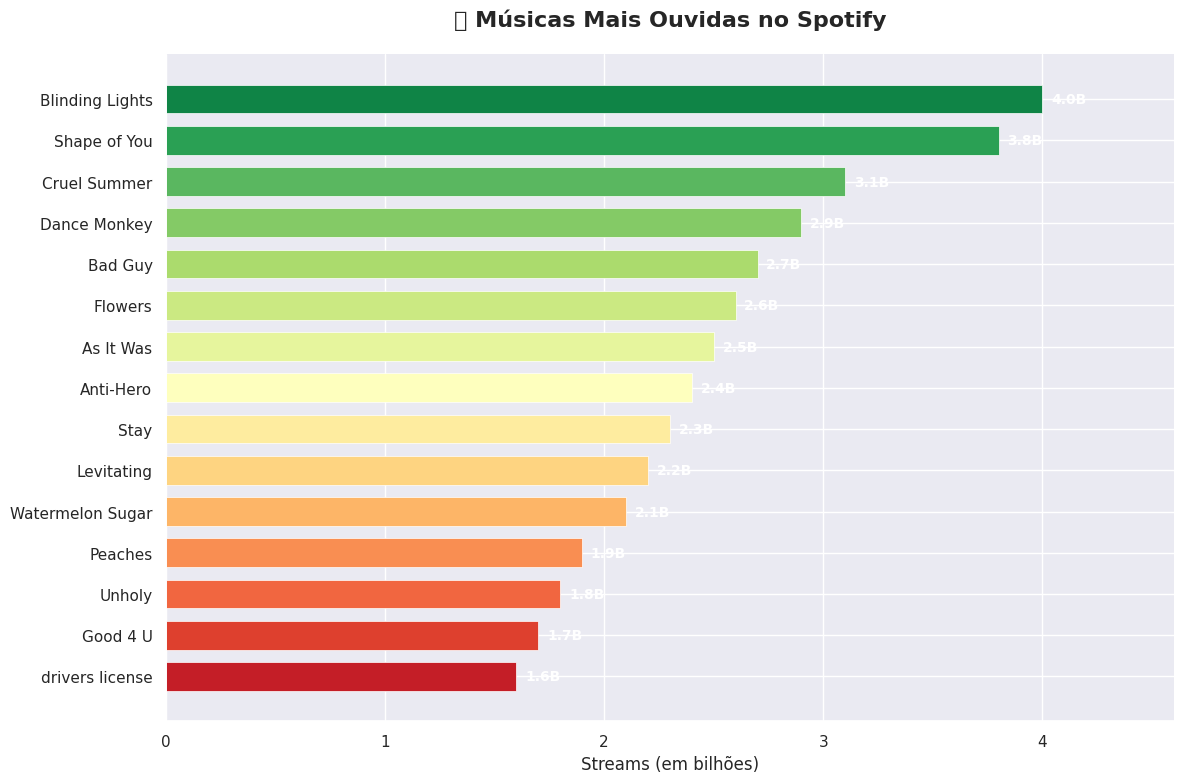

💾 Salvo como grafico_streams.png


In [4]:
df_ord = df.sort_values('streams_bilhoes', ascending=True)
cores = sns.color_palette('RdYlGn', n_colors=len(df))

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_ord['musica'], df_ord['streams_bilhoes'],
               color=cores, edgecolor='white', linewidth=0.5, height=0.7)

# Adiciona o valor no final de cada barra
for bar, val in zip(bars, df_ord['streams_bilhoes']):
    ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}B', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_title('🏆 Músicas Mais Ouvidas no Spotify', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Streams (em bilhões)', fontsize=12)
ax.set_xlim(0, df['streams_bilhoes'].max() + 0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico_streams.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Salvo como grafico_streams.png')

## 🎯 Célula 5 — Gráfico de bolhas interativo: Energia × Popularidade

Passe o mouse por cima das bolhas para ver os detalhes!

In [5]:
fig = px.scatter(
    df,
    x='energia',
    y='popularidade',
    size='streams_bilhoes',
    color='genero',
    hover_name='musica',
    hover_data={'artista': True, 'streams_bilhoes': ':.1f', 'energia': True, 'popularidade': True, 'genero': False},
    size_max=50,
    title='🎯 Energia × Popularidade (tamanho = streams)',
    labels={'energia': 'Energia da Música (0-100)', 'popularidade': 'Popularidade (0-100)', 'genero': 'Gênero'},
    template='plotly_dark'
)
fig.update_layout(font=dict(size=13), legend=dict(title='Gênero', x=1.02), height=550)
fig.show()

## 🥧 Célula 6 — Gráfico de pizza: Distribuição de gêneros

In [6]:
contagem_generos = df['genero'].value_counts()

fig = px.pie(
    values=contagem_generos.values,
    names=contagem_generos.index,
    title='🥧 Distribuição de Gêneros Musicais',
    color_discrete_sequence=px.colors.qualitative.Set3,
    hole=0.35
)
fig.update_traces(textposition='outside', textinfo='percent+label', pull=[0.05] * len(contagem_generos))
fig.update_layout(height=500, showlegend=True, template='plotly_dark')
fig.show()

## 🔥 Célula 7 — Heatmap: Correlação entre variáveis

Correlação mostra se duas variáveis andam juntas: +1 = sempre juntas, -1 = sempre opostas, 0 = sem relação.

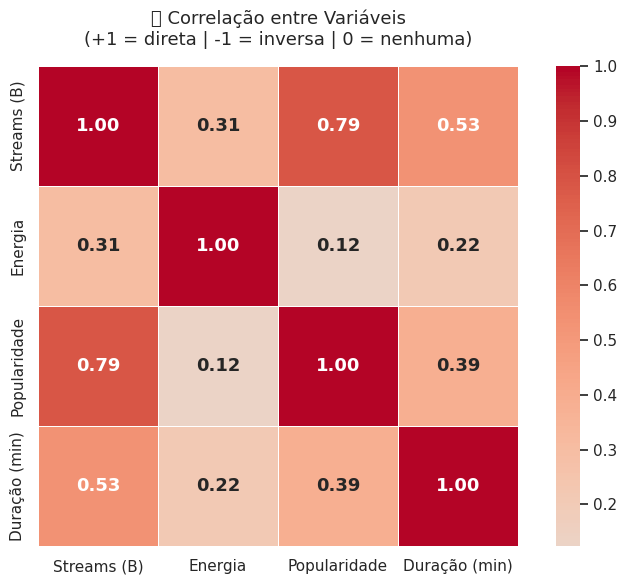

💾 Salvo como grafico_correlacao.png


In [7]:
colunas = df[['streams_bilhoes', 'energia', 'popularidade', 'duracao_min']].copy()
colunas.columns = ['Streams (B)', 'Energia', 'Popularidade', 'Duração (min)']
correlacao = colunas.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('🔥 Correlação entre Variáveis\n(+1 = direta | -1 = inversa | 0 = nenhuma)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('grafico_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Salvo como grafico_correlacao.png')

## 📤 Célula 8 — Exportar os dados tratados

In [8]:
df.to_csv('musicas_analisadas.csv', index=False, encoding='utf-8-sig')

print('✅ Arquivos gerados:')
print('   📊 musicas_analisadas.csv   → tabela completa (abre no Excel)')
print('   🖼  grafico_streams.png      → gráfico de barras')
print('   🖼  grafico_correlacao.png   → heatmap de correlação')
print()
print('💡 Para baixar: clique na pasta 📁 no painel esquerdo do Colab')
print('   Clique com botão direito no arquivo → Download')

✅ Arquivos gerados:
   📊 musicas_analisadas.csv   → tabela completa (abre no Excel)
   🖼  grafico_streams.png      → gráfico de barras
   🖼  grafico_correlacao.png   → heatmap de correlação

💡 Para baixar: clique na pasta 📁 no painel esquerdo do Colab
   Clique com botão direito no arquivo → Download


## 🎉 Parabéns!

Veja o que você aprendeu:

| Conceito | Onde foi usado |
|---|---|
| `DataFrame` com pandas | Célula 2 — criou e manipulou a tabela |
| `.groupby()` | Célula 3 — agrupou por gênero |
| Gráfico de barras | Célula 4 — matplotlib + seaborn |
| Gráfico interativo | Célula 5 — plotly com hover |
| Gráfico de pizza | Célula 6 — distribuição de categorias |
| Heatmap de correlação | Célula 7 — relação entre variáveis |
| Exportar CSV e PNG | Célula 8 — salvou os resultados |

### 🚀 Próximos passos
- Troque os dados pelas suas músicas favoritas
- Adicione mais colunas (ex: ano de lançamento, BPM)
- Tente criar um gráfico de linha mostrando evolução no tempo